3장 분류와 회귀

In [ ]:
# 예제 3.1 이진 분류

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# 학습 데이터 준비
x_train = np.array([[1, 1, 0], [1, 0, 0], [0, 0, 1], [0, 1, 1]])   # 학습 데이터
y_train = np.array([[0], [0], [1], [1]])   # 레이블

In [ ]:
# 모델 생성
inputs = Input(shape=(3, ))   # 입력 특징 3개
outputs = Dense(1,   # 출력층 뉴런 1개
                activation='sigmoid',   # sigmoid 함수 사용
                kernel_initializer=RandomNormal(seed=77))(inputs)

model = Model(inputs, outputs)

In [ ]:
# 모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.1),   # 학습률 0.1
              loss='binary_crossentropy')

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=30, verbose=0)   # 30회 반복

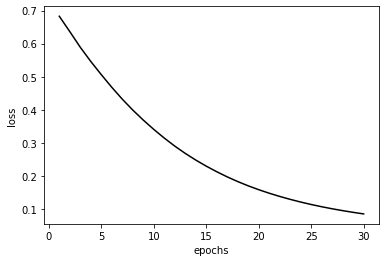

In [ ]:
# 학습 결과 시각화
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], color='black')
plt.xlabel('epochs')
plt.ylabel('loss')

plt.show()

In [ ]:
# 모델 예측
x_test = np.array([[1, 1, 0], [1, 0, 0], [0, 0, 1], [0, 1, 1]])  # 테스트 데이터
y_test = np.array([[0], [0], [1], [1]])   # 테스트 정답

model.predict(x_test).round(2)   # 예측

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[0.07],
       [0.08],
       [0.92],
       [0.92]], dtype=float32)

In [ ]:
# 예제 3.2 선형 회귀

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 데이터셋 준비
np.random.seed(777)

x_train = np.random.uniform(0, 10, 200)   # 0 ~ 10의 균등 분포 랜덤값 200개
y_train = 2 * x_train + 1 + np.random.randn(200)   # 정규 분포 랜덤값 200개

print(x_train.shape, y_train.shape, "\n")   # x_train와 y_train shape 확인
print(f"x_train: {x_train[:3].round(1)}")   # 처음 3개 샘플 확인
print(f"y_train: {y_train[:3].round(1)}")

(200,) (200,) 

x_train: [1.5 3.  0.6]
y_train: [4.2 8.6 2.1]


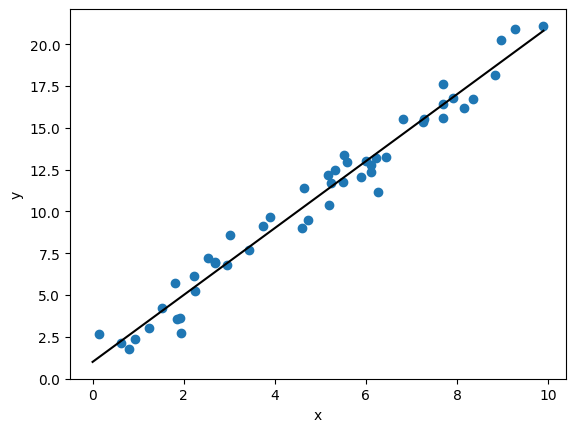

In [ ]:
# 데이터 시각화
x = np.arange(0, 10, 0.1)
y = 2 * x + 1

plt.scatter(x_train[:50], y_train[:50])   # 처음 50개 샘플 표현
plt.plot(x, y, color='black')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

In [ ]:
# 학습 데이터/테스트 데이터 분할
x_train, x_test, y_train, y_test = train_test_split(
    x_train, y_train,
    test_size=0.2,   # 분할 비율 0.2
    random_state=77)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(160,) (160,)
(40,) (40,)


In [ ]:
# 모델 생성
inputs = Input(shape=(1, ))   # 입력 특징 1개
outputs = Dense(1,   # 출력층 뉴런 1개
                kernel_initializer=RandomNormal(seed=77))(inputs)

model = Model(inputs, outputs)

In [ ]:
#  모델 컴파일
model.compile(optimizer=Adam(learning_rate=0.1),
              loss='mse',   # 손실 함수 MSE 사용
              metrics=['mae'])   # 성능 평가 지표 MAE 사용

In [ ]:
# 모델 학습
model.fit(x_train, y_train, epochs=50)   # verbose=1 기본값 사용

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 125.2547 - mae: 9.6899   
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 76.4391 - mae: 7.6347  
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.1583 - mae: 4.6629 
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.0029 - mae: 2.3774  
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3451 - mae: 0.9568 
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3770 - mae: 1.2712 
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0161 - mae: 1.7692 
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1733 - mae: 1.8022 
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5619 - mae: 1.3785 
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4918 - mae: 1.0061 
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0374 - mae: 0.8382 
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2472 - mae: 0.9022 
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0783 - mae: 0.8163  


[1.0454868078231812, 0.7988055944442749]

In [ ]:
# 모델 예측
x = np.array([1, 3, 5, 7, 9])

model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[ 3.0797062],
       [ 7.034698 ],
       [10.989689 ],
       [14.944681 ],
       [18.899673 ]], dtype=float32)